# Smart Parking — Component Benchmark

Test từng thành phần AI riêng biệt, đo latency / accuracy / throughput.

### Components:
1. **PlateDetector** — YOLOv8n plate detection (data riêng)
2. **PlateOCRYolo + Validator** — YOLOv8n character recognition (data riêng, YOLO labels)
3. **FaceEngine** — InsightFace detection + embedding (LFW dataset)
4. **ParkingDB** — pgvector cosine search (dùng embedding thật từ LFW)
5. **End-to-End Pipeline** — Full flow benchmark

In [2]:
import numpy as np
import cv2
import time
import os
import sys
import glob
import json
import logging
import random
from pathlib import Path
from collections import defaultdict, Counter

%matplotlib inline
import matplotlib
# matplotlib.use('Agg')  # Fix cho Jetson không có display
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.15,
    'font.size': 11,
})

C = {
    'green': '#22c55e', 'blue': '#3b82f6', 'yellow': '#eab308',
    'red': '#ef4444', 'purple': '#a855f7', 'cyan': '#06b6d4',
    'orange': '#f97316', 'pink': '#ec4899',
}

logging.basicConfig(level=logging.WARNING)
print('Imports OK')

Imports OK


In [3]:
PROJECT_DIR = Path('/home/somethink/parking_system')
sys.path.insert(0, str(PROJECT_DIR))

# ── 1) PLATE DETECTION DATA ──
DET_IMAGES_DIR = 'yolo_plate_data/images/val'
DET_LABELS_DIR = 'yolo_plate_data/labels/val'

# ── 2) PLATE RECOGNITION (OCR) DATA ──
OCR_IMAGES_DIR = 'yolo_plate_ocr_data/images/val'
OCR_LABELS_DIR = 'yolo_plate_ocr_data/labels/val'
OCR_TEXT_GT = 'paddle_format/0rec_gt.txt'

# ── 3) FACE DATA — tự download LFW ──
LFW_DIR = str(PROJECT_DIR / 'benchmark_data' / 'lfw_funneled')

# ── Model paths ──
PLATE_MODEL = str(PROJECT_DIR / 'models' / 'plate_yolov8n.engine')
OCR_MODEL = str(PROJECT_DIR / 'models' / 'plate_ocr_yolov8n.engine')

# ── Benchmark params ──
N_WARMUP = 5
N_BENCH  = 100

# ── OCR model params ──
OCR_IMGSZ = 320
OCR_CONF = 0.3
OCR_DEVICE = 0

# ── Validate paths ──
def check_dir(name, path):
    if not path:
        print(f'  ⚠️  {name}: CHƯA SET')
        return False
    p = Path(path)
    if p.is_dir():
        n = len(list(p.iterdir()))
        print(f'  ✅ {name}: {path} ({n} files)')
        return True
    print(f'  ❌ {name}: KHÔNG TỒN TẠI')
    return False

print('Checking paths:')
HAS_DET_IMG = check_dir('Det images', DET_IMAGES_DIR)
HAS_DET_LBL = check_dir('Det labels', DET_LABELS_DIR)
HAS_DET = HAS_DET_IMG and HAS_DET_LBL
HAS_OCR_IMG = check_dir('OCR images', OCR_IMAGES_DIR)
HAS_OCR_LBL = check_dir('OCR labels', OCR_LABELS_DIR)
HAS_OCR = HAS_OCR_IMG and HAS_OCR_LBL
HAS_LFW = check_dir('LFW faces', LFW_DIR)
print(f'  {"✅" if os.path.exists(PLATE_MODEL) else "❌"} Plate model: {PLATE_MODEL}')
print(f'  {"✅" if os.path.exists(OCR_MODEL) else "❌"} OCR model: {OCR_MODEL}')
print(f'  {"✅" if os.path.exists(OCR_TEXT_GT) else "⚠️"} OCR text GT: {OCR_TEXT_GT}')

Checking paths:
  ✅ Det images: yolo_plate_data/images/val (1651 files)
  ✅ Det labels: yolo_plate_data/labels/val (1651 files)
  ✅ OCR images: yolo_plate_ocr_data/images/val (514 files)
  ✅ OCR labels: yolo_plate_ocr_data/labels/val (636 files)
  ✅ LFW faces: /home/somethink/parking_system/benchmark_data/lfw_funneled (5760 files)
  ✅ Plate model: /home/somethink/parking_system/models/plate_yolov8n.engine
  ✅ OCR model: /home/somethink/parking_system/models/plate_ocr_yolov8n.engine
  ✅ OCR text GT: paddle_format/0rec_gt.txt


In [4]:
def bench(func, n=N_BENCH, warmup=N_WARMUP, label=''):
    """Benchmark 1 function → dict latency stats."""
    for _ in range(warmup):
        func()
    times = []
    for _ in range(n):
        t0 = time.perf_counter()
        func()
        times.append((time.perf_counter() - t0) * 1000)
    arr = np.array(times)
    s = {
        'label': label, 'n': n,
        'mean': arr.mean(), 'std': arr.std(),
        'min': arr.min(), 'max': arr.max(),
        'p50': np.percentile(arr, 50),
        'p95': np.percentile(arr, 95),
        'p99': np.percentile(arr, 99),
        'fps': 1000.0 / arr.mean() if arr.mean() > 0 else 0,
        'raw': arr,
    }
    print(f'  {label:30s}  avg={s["mean"]:7.2f}ms  '
          f'p95={s["p95"]:7.2f}ms  fps={s["fps"]:6.1f}')
    return s

def iou_calc(a, b):
    x1=max(a[0],b[0]); y1=max(a[1],b[1])
    x2=min(a[2],b[2]); y2=min(a[3],b[3])
    inter = max(0,x2-x1)*max(0,y2-y1)
    union = (a[2]-a[0])*(a[3]-a[1])+(b[2]-b[0])*(b[3]-b[1])-inter
    return inter/max(union,1e-6)

def edit_distance(s1, s2):
    m, n = len(s1), len(s2)
    dp = [[0]*(n+1) for _ in range(m+1)]
    for i in range(m+1): dp[i][0] = i
    for j in range(n+1): dp[0][j] = j
    for i in range(1, m+1):
        for j in range(1, n+1):
            dp[i][j] = min(dp[i-1][j]+1, dp[i][j-1]+1,
                           dp[i-1][j-1]+(0 if s1[i-1]==s2[j-1] else 1))
    return dp[m][n]


def pad_to_square(img):
    """
    Pad ảnh về hình vuông (max dimension).
    TensorRT engine export 640x640 cố định — nếu truyền ảnh
    không vuông, ultralytics letterbox thành shape lệch (vd 416x640)
    → TRT reject. Pad trước để YOLO resize về đúng 640x640.
    """
    h, w = img.shape[:2]
    if h == w:
        return img
    size = max(h, w)
    padded = np.zeros((size, size, 3), dtype=np.uint8)
    padded[:h, :w] = img
    return padded

print('Helpers ready (with pad_to_square for TRT)')


Helpers ready (with pad_to_square for TRT)


---
## 1. PlateDetector — YOLOv8n Detection
**Data**: ảnh gốc (1 folder) + YOLO labels (folder riêng)  
**Đo**: latency theo resolution, accuracy (P/R/F1 @ IoU≥0.5)

In [4]:
from engine import PlateDetector

print('Loading PlateDetector...')
plate_det = PlateDetector(PLATE_MODEL, imgsz=640, conf=0.4, device=0)
print('Done.\n')

# ══════════════════════════════════════════════════════════════
# TensorRT engine export cố định 640x640.
# → Benchmark dùng ảnh vuông (synthetic) + ảnh thật (pad square)
# ══════════════════════════════════════════════════════════════

det_latency = []
print('=== Latency ===')

# 1) Pure inference — 640x640 synthetic (no real detections → NMS trivial)
#    Chỉ đo forward pass, KHÔNG đại diện cho latency thật.
img_sq = np.random.randint(0, 255, (640, 640, 3), dtype=np.uint8)
s = bench(lambda: plate_det(img_sq), n=N_BENCH, label='Det 640x640 (inference-only)')
det_latency.append(s)

# 2) Ảnh thật từ dataset — pad to square trước khi gọi detector
#    Đây là metric chính: bao gồm NMS trên real detections.
#    Đây là metric chính: bao gồm NMS trên real detections.
if HAS_DET:
    real_paths = sorted(
        glob.glob(os.path.join(DET_IMAGES_DIR, '*.jpg')) +
        glob.glob(os.path.join(DET_IMAGES_DIR, '*.png'))
    )[:50]
    loaded = [cv2.imread(p) for p in real_paths if cv2.imread(p) is not None]
    loaded = [img for img in loaded if img is not None][:50]
    if loaded:
        h0, w0 = loaded[0].shape[:2]
        print(f'  Real images: {len(loaded)} loaded, sample={w0}x{h0}')
        idx = [0]
        def det_real():
            img = loaded[idx[0] % len(loaded)]
            idx[0] += 1
            return plate_det(pad_to_square(img))
        s = bench(det_real, n=min(N_BENCH, len(loaded)*3), label=f'Det real {w0}x{h0} (padded)')
        det_latency.append(s)
else:
    # Fallback: ảnh vuông lớn hơn (YOLO resize → 640x640)
    img_lg = np.random.randint(0, 255, (1280, 1280, 3), dtype=np.uint8)
    s = bench(lambda: plate_det(img_lg), n=N_BENCH, label='Det 1280x1280 (inference-only)')
    det_latency.append(s)


Loading PlateDetector...
Loading /home/somethink/parking_system/models/plate_yolov8n.engine for TensorRT inference...
[04/06/2026-21:20:24] [TRT] [I] Loaded engine size: 8 MiB
[04/06/2026-21:20:24] [TRT] [W] Using an engine plan file across different models of devices is not recommended and is likely to affect performance or even cause errors.
[04/06/2026-21:20:24] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +15, now: CPU 0, GPU 20 (MiB)
WARNING ⚠️ Metadata not found for 'model=/home/somethink/parking_system/models/plate_yolov8n.engine'
Done.

=== Latency ===
  Det 640x640 (inference-only)    avg=  21.07ms  p95=  23.23ms  fps=  47.5
  Real images: 50 loaded, sample=472x303
  Det real 472x303 (padded)       avg=  30.45ms  p95=  31.25ms  fps=  32.8


In [5]:
# ── Accuracy trên detection dataset ──
det_acc = None

if not HAS_DET:
    print('⚠️  SKIP — chưa set DET_IMAGES_DIR và/hoặc DET_LABELS_DIR')
    print('   Sửa ở cell [config] rồi chạy lại.')
else:
    # Tìm ảnh-label pairs
    all_imgs = sorted(
        glob.glob(os.path.join(DET_IMAGES_DIR, '*.jpg')) +
        glob.glob(os.path.join(DET_IMAGES_DIR, '*.jpeg')) +
        glob.glob(os.path.join(DET_IMAGES_DIR, '*.png'))
    )
    pairs = []
    for img_p in all_imgs:
        lbl_p = os.path.join(DET_LABELS_DIR, Path(img_p).stem + '.txt')
        if os.path.exists(lbl_p):
            pairs.append((img_p, lbl_p))
    
    if len(pairs) > 500:
        random.seed(42)
        pairs = random.sample(pairs, 500)
    
    print(f'Found {len(pairs)} image-label pairs')
    
    det_acc = {'tp':0, 'fp':0, 'fn':0, 'confs':[], 'n_dets':[], 'times_ms':[]}
    
    for img_p, lbl_p in pairs:
        img = cv2.imread(img_p)
        if img is None: continue
        h, w = img.shape[:2]
        
        t0 = time.perf_counter()
        dets = plate_det(pad_to_square(img))  # pad cho TRT 640x640
        det_acc['times_ms'].append((time.perf_counter()-t0)*1000)
        det_acc['n_dets'].append(len(dets))
        
        # Parse YOLO labels
        gt_boxes = []
        with open(lbl_p) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5: continue
                cx,cy,bw,bh = map(float, parts[1:5])
                gt_boxes.append((
                    int((cx-bw/2)*w), int((cy-bh/2)*h),
                    int((cx+bw/2)*w), int((cy+bh/2)*h)
                ))
        
        # Greedy match (IoU ≥ 0.5)
        matched = set()
        for det in sorted(dets, key=lambda d: d['conf'], reverse=True):
            det_acc['confs'].append(det['conf'])
            best_iou, best_gi = 0, -1
            for gi, gt in enumerate(gt_boxes):
                if gi in matched: continue
                v = iou_calc(det['bbox'], gt)
                if v > best_iou: best_iou, best_gi = v, gi
            if best_iou >= 0.5 and best_gi >= 0:
                det_acc['tp'] += 1; matched.add(best_gi)
            else:
                det_acc['fp'] += 1
        det_acc['fn'] += len(gt_boxes) - len(matched)
    
    tp,fp,fn = det_acc['tp'], det_acc['fp'], det_acc['fn']
    prec = tp/max(tp+fp,1); rec = tp/max(tp+fn,1)
    f1 = 2*prec*rec/max(prec+rec,1e-6)
    
    print(f'\n  TP={tp}  FP={fp}  FN={fn}')
    print(f'  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}')
    if det_acc['times_ms']:
        print(f'  Avg inference: {np.mean(det_acc["times_ms"]):.1f}ms (real images)')

Found 500 image-label pairs

  TP=502  FP=3  FN=1
  Precision=0.9941  Recall=0.9980  F1=0.9960
  Avg inference: 28.6ms (real images)


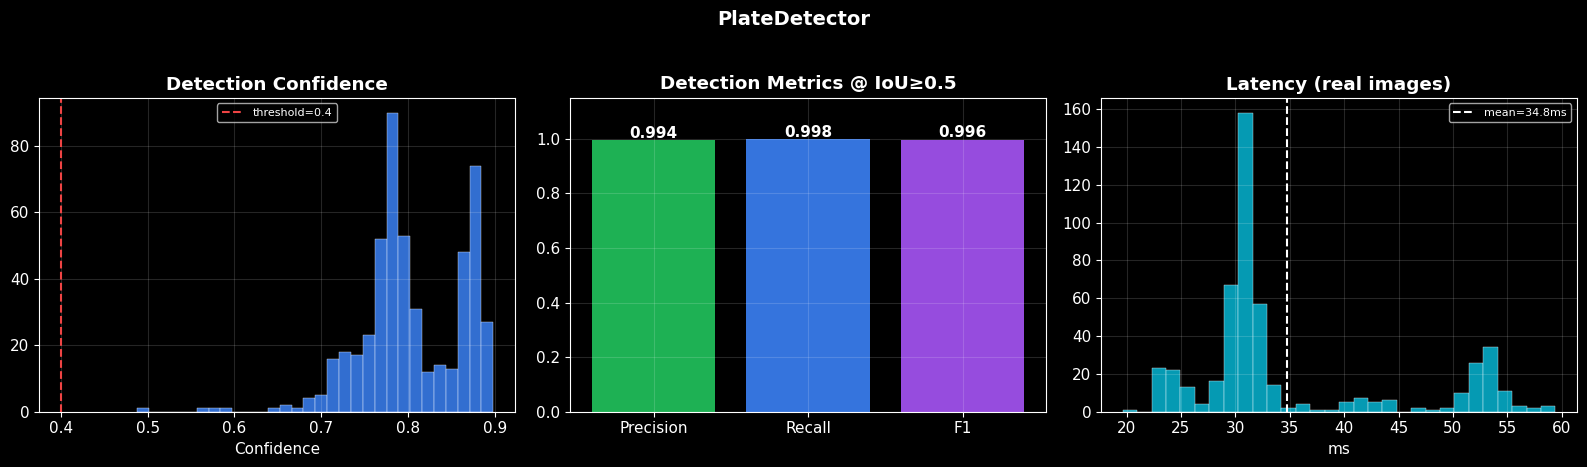

In [6]:
if det_acc and (det_acc['tp']+det_acc['fp']) > 0:
    tp,fp,fn = det_acc['tp'], det_acc['fp'], det_acc['fn']
    prec=tp/max(tp+fp,1); rec=tp/max(tp+fn,1)
    f1=2*prec*rec/max(prec+rec,1e-6)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    
    axes[0].hist(det_acc['confs'], bins=30, color=C['blue'], alpha=0.85, edgecolor='white', linewidth=0.3)
    axes[0].axvline(0.4, color=C['red'], linestyle='--', label='threshold=0.4')
    axes[0].set_title('Detection Confidence', fontweight='bold')
    axes[0].set_xlabel('Confidence'); axes[0].legend(fontsize=8)

    bars = axes[1].bar(['Precision','Recall','F1'], [prec,rec,f1],
                        color=[C['green'],C['blue'],C['purple']], alpha=0.9)
    for b,v in zip(bars,[prec,rec,f1]):
        axes[1].text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}',
                     ha='center', fontsize=11, fontweight='bold')
    axes[1].set_ylim(0,1.15); axes[1].set_title('Detection Metrics @ IoU≥0.5', fontweight='bold')

    axes[2].hist(det_acc['times_ms'], bins=30, color=C['cyan'], alpha=0.85, edgecolor='white', linewidth=0.3)
    axes[2].axvline(np.mean(det_acc['times_ms']), color='white', linestyle='--',
                    label=f'mean={np.mean(det_acc["times_ms"]):.1f}ms')
    axes[2].set_title('Latency (real images)', fontweight='bold')
    axes[2].set_xlabel('ms'); axes[2].legend(fontsize=8)

    plt.suptitle('PlateDetector', fontsize=14, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.savefig('/tmp/bench_det.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('Không có detection accuracy data để vẽ')

---
## 2. PlateOCRYolo
> Updated 2026-04-06: benchmark OCR dùng trực tiếp text GT từ `paddle_format/0rec_gt.txt`; metric chính là `char-level`, kèm `string-level` và `pipeline-level`.
**Data**: ảnh crop biển số từ `yolo_plate_ocr_data/images/val` + YOLO char labels trong `yolo_plate_ocr_data/labels/val` + text GT trong `paddle_format/0rec_gt.txt`  
**Đo**: latency, char-level precision/recall/F1 (primary), plate-string accuracy, và metric sau `PlateValidator`


In [5]:
from engine import PlateOCRYolo
from main import PlateValidator

print('Loading PlateOCRYolo...')
plate_ocr = PlateOCRYolo(OCR_MODEL, imgsz=OCR_IMGSZ, conf=OCR_CONF, device=OCR_DEVICE)
validator = PlateValidator()
print('Done.\n')

# ── Latency (synthetic crops) ──
# Noise crop → 0 chars detected → NMS + sort/decode bị skip.
# Chỉ đo pure inference, KHÔNG đại diện cho latency thật.
ocr_latency = []
print('=== OCR YOLO Latency (inference-only, synthetic) ===')
for name, (w,h) in [('80x24',(80,24)),('160x48',(160,48)),('320x96',(320,96)),('480x140',(480,140))]:
    crop = np.random.randint(0,255,(h,w,3), dtype=np.uint8)
    s = bench(lambda c=crop: plate_ocr(c), n=N_BENCH, label=f'OCR {name} (inference-only)')
    ocr_latency.append(s)

# ── Latency (real crops) — metric chính ──
# Ảnh thật có ký tự → đo đầy đủ: inference + NMS + sort + decode.
if HAS_OCR:
    real_paths = sorted(
        glob.glob(os.path.join(OCR_IMAGES_DIR, '*.jpg')) +
        glob.glob(os.path.join(OCR_IMAGES_DIR, '*.jpeg')) +
        glob.glob(os.path.join(OCR_IMAGES_DIR, '*.png'))
    )[:50]
    loaded = [cv2.imread(p) for p in real_paths]
    loaded = [img for img in loaded if img is not None]
    if loaded:
        h0, w0 = loaded[0].shape[:2]
        print(f'\n=== OCR YOLO Latency (real crops) ===')
        print(f'  Real OCR crops: {len(loaded)} loaded, sample={w0}x{h0}')
        idx = [0]
        def ocr_real():
            crop = loaded[idx[0] % len(loaded)]
            idx[0] += 1
            return plate_ocr(crop)
        s = bench(ocr_real, n=min(N_BENCH, len(loaded)*3), label=f'OCR real {w0}x{h0}')
        ocr_latency.append(s)


Loading PlateOCRYolo...
Loading /home/somethink/parking_system/models/plate_ocr_yolov8n.engine for TensorRT inference...
[04/07/2026-21:57:19] [TRT] [I] Loaded engine size: 7 MiB
[04/07/2026-21:57:19] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +3, now: CPU 0, GPU 8 (MiB)
Done.

=== OCR YOLO Latency (inference-only, synthetic) ===
  OCR 80x24 (inference-only)      avg=  10.59ms  p95=  11.26ms  fps=  94.4
  OCR 160x48 (inference-only)     avg=   9.67ms  p95=  10.59ms  fps= 103.4
  OCR 320x96 (inference-only)     avg=   9.01ms  p95=   9.44ms  fps= 111.0
  OCR 480x140 (inference-only)    avg=   9.46ms  p95=   9.88ms  fps= 105.7

=== OCR YOLO Latency (real crops) ===
  Real OCR crops: 50 loaded, sample=760x560
  OCR real 760x560                avg=  13.62ms  p95=  14.12ms  fps=  73.4


In [6]:
import csv
from pathlib import Path

OCR_CHAR_IOU = 0.5
OCR_TEXT_SAMPLE_LIMIT = 500


def class_id_to_char(class_id: int) -> str:
    if 0 <= class_id <= 9:
        return str(class_id)
    if 10 <= class_id <= 35:
        return chr(ord('A') + class_id - 10)
    raise ValueError(f'class_id ngoài phạm vi hỗ trợ: {class_id}')


def parse_yolo_label_file(label_path: Path):
    objects = []
    with open(label_path, 'r', encoding='utf-8') as f:
        for line_num, raw_line in enumerate(f, start=1):
            line = raw_line.strip()
            if not line:
                continue

            parts = line.split()
            if len(parts) < 5:
                print(f'[WARN] {label_path} dòng {line_num}: không đủ 5 phần tử -> bỏ qua')
                continue

            try:
                class_id = int(parts[0])
                cx = float(parts[1])
                cy = float(parts[2])
                w = float(parts[3])
                h = float(parts[4])
                ch = class_id_to_char(class_id)
            except Exception as e:
                print(f'[WARN] {label_path} dòng {line_num}: parse lỗi -> {e}')
                continue

            objects.append({
                'char': ch,
                'cls_id': class_id,
                'cx': cx,
                'cy': cy,
                'w': w,
                'h': h,
            })
    return objects


def yolo_obj_to_xyxy(obj: dict, img_w: int, img_h: int):
    return (
        float((obj['cx'] - obj['w'] / 2) * img_w),
        float((obj['cy'] - obj['h'] / 2) * img_h),
        float((obj['cx'] + obj['w'] / 2) * img_w),
        float((obj['cy'] + obj['h'] / 2) * img_h),
    )


def prepare_ocr_crop(plate_crop: np.ndarray) -> np.ndarray:
    if plate_crop is None or plate_crop.size == 0:
        return plate_crop
    h = plate_crop.shape[0]
    if h < 48:
        scale = 48.0 / h
        plate_crop = cv2.resize(
            plate_crop, None, fx=scale, fy=scale,
            interpolation=cv2.INTER_CUBIC)
    return plate_crop


def run_ocr_model(plate_crop: np.ndarray):
    crop = prepare_ocr_crop(plate_crop)
    if crop is None or crop.size == 0:
        return crop, []

    results = plate_ocr.model(
        crop, imgsz=plate_ocr.imgsz,
        conf=plate_ocr.conf, verbose=False)

    chars = []
    for r in results:
        boxes = getattr(r, 'boxes', None)
        if boxes is None:
            continue
        xyxy = boxes.xyxy.cpu().numpy() if hasattr(boxes.xyxy, 'cpu') else boxes.xyxy.numpy()
        confs = boxes.conf.cpu().numpy() if hasattr(boxes.conf, 'cpu') else boxes.conf.numpy()
        clss = boxes.cls.cpu().numpy().astype(int) if hasattr(boxes.cls, 'cpu') else boxes.cls.numpy().astype(int)
        for box, cf, cls_id in zip(xyxy, confs, clss):
            x1, y1, x2, y2 = map(float, box)
            chars.append({
                'char': class_id_to_char(int(cls_id)),
                'cls_id': int(cls_id),
                'conf': float(cf),
                'cx': float((x1 + x2) / 2 / crop.shape[1]),
                'cy': float((y1 + y2) / 2 / crop.shape[0]),
                'w': float((x2 - x1) / crop.shape[1]),
                'h': float((y2 - y1) / crop.shape[0]),
                'xyxy': (x1, y1, x2, y2),
            })
    return crop, chars


def sort_chars_by_rows(objects: list, img_h: int = 0, row_gap_ratio: float = 0.18):
    """
    Sort ký tự theo vị trí — cùng ý tưởng robust với engine.py _sort_chars.

    Thay vì dùng y_range thô, hàm này fit một đường y(x) để loại bỏ tilt,
    rồi chỉ tách 2 dòng khi residual theo y đủ lớn và hai cụm còn overlap
    theo trục x.
    """
    ordered = sorted(objects, key=lambda o: o['cx'])
    if len(ordered) < 4:
        return ordered

    xs = np.array([o['cx'] for o in ordered], dtype=np.float32)
    ys = np.array([o['cy'] for o in ordered], dtype=np.float32)
    x_mean = float(xs.mean())
    y_mean = float(ys.mean())
    x_var = float(np.sum((xs - x_mean) ** 2))
    if x_var <= 1e-6:
        return ordered

    slope = float(np.sum((xs - x_mean) * (ys - y_mean)) / x_var)
    residuals = ys - (y_mean + slope * (xs - x_mean))
    residual_range = float(residuals.max() - residuals.min())
    heights = sorted(o.get('h', 0.0) for o in ordered if o.get('h', 0.0) > 0)
    median_h = heights[len(heights) // 2] if heights else 0.2
    split_threshold = max(row_gap_ratio, median_h * 0.6)
    if residual_range <= split_threshold:
        return ordered

    residual_mid = float((residuals.min() + residuals.max()) / 2)
    upper = [o for o, r in zip(ordered, residuals) if r < residual_mid]
    lower = [o for o, r in zip(ordered, residuals) if r >= residual_mid]
    if len(upper) < 2 or len(lower) < 2:
        return ordered

    upper_x_min = min(o['cx'] for o in upper)
    upper_x_max = max(o['cx'] for o in upper)
    lower_x_min = min(o['cx'] for o in lower)
    lower_x_max = max(o['cx'] for o in lower)
    if upper_x_max < lower_x_min or lower_x_max < upper_x_min:
        return ordered

    upper = sorted(upper, key=lambda o: o['cx'])
    lower = sorted(lower, key=lambda o: o['cx'])
    upper_y = sum(o['cy'] for o in upper) / len(upper)
    lower_y = sum(o['cy'] for o in lower) / len(lower)
    if upper_y > lower_y:
        upper, lower = lower, upper
    return upper + lower


def decode_pred_chars(pred_chars: list, crop_h: int):
    ordered = sort_chars_by_rows(pred_chars, img_h=crop_h)
    raw = ''.join(obj['char'] for obj in ordered)
    conf = float(np.mean([obj.get('conf', 0.0) for obj in ordered])) if ordered else 0.0
    return raw, conf


def normalize_ocr_text(text: str) -> str:
    if text is None:
        return ''
    text = str(text).strip().upper()
    for ch in [' ', '-', '.', '_']:
        text = text.replace(ch, '')
    return text


def edit_distance(a: str, b: str) -> int:
    if a == b:
        return 0
    if not a:
        return len(b)
    if not b:
        return len(a)

    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, start=1):
        curr = [i]
        for j, cb in enumerate(b, start=1):
            cost = 0 if ca == cb else 1
            curr.append(min(
                prev[j] + 1,
                curr[j - 1] + 1,
                prev[j - 1] + cost,
            ))
        prev = curr
    return prev[-1]


def load_ocr_text_gt_map(path: str):
    gt_map = {}
    p = Path(path)
    if not p.exists():
        return gt_map

    with open(p, 'r', encoding='utf-8') as f:
        for line_num, raw_line in enumerate(f, start=1):
            line = raw_line.strip()
            if not line:
                continue

            if '	' in line:
                image_name, text = line.split('	', 1)
            elif ',' in line and line_num == 1 and 'image' in line.lower() and 'text' in line.lower():
                continue
            elif ',' in line:
                image_name, text = line.split(',', 1)
            else:
                print(f'[WARN] OCR text GT dòng {line_num} không đúng format -> bỏ qua: {line[:80]}')
                continue

            image_name = image_name.strip()
            text = normalize_ocr_text(text)
            if not image_name:
                continue
            gt_map[Path(image_name).name] = text
            gt_map[Path(image_name).stem] = text
    return gt_map


def load_ocr_samples(images_dir: str, labels_dir: str):
    img_dir = Path(images_dir)
    lbl_dir = Path(labels_dir)
    samples = []

    for img_path in sorted(img_dir.iterdir()):
        if img_path.suffix.lower() not in {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}:
            continue
        label_path = lbl_dir / f'{img_path.stem}.txt'
        if not label_path.exists():
            continue
        gt_chars = parse_yolo_label_file(label_path)
        samples.append({
            'img_path': str(img_path),
            'label_path': str(label_path),
            'gt_chars': gt_chars,
        })
    return samples


def box_iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)
    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter = inter_w * inter_h
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter
    if union <= 0:
        return 0.0
    return inter / union


def match_char_boxes(pred_chars: list, gt_chars: list, crop_shape, iou_thr: float = OCR_CHAR_IOU):
    img_h, img_w = crop_shape[:2]
    preds = []
    for pred in pred_chars:
        box = pred.get('xyxy')
        if box is None:
            box = yolo_obj_to_xyxy(pred, img_w, img_h)
        preds.append({**pred, 'xyxy': box})

    gts = [{**gt, 'xyxy': yolo_obj_to_xyxy(gt, img_w, img_h)} for gt in gt_chars]

    pairs = []
    for pi, pred in enumerate(preds):
        for gi, gt in enumerate(gts):
            iou = box_iou_xyxy(pred['xyxy'], gt['xyxy'])
            if iou >= iou_thr:
                pairs.append((iou, pi, gi))
    pairs.sort(reverse=True)

    matched_pred = set()
    matched_gt = set()
    tp = 0
    cls_err = 0
    confusions = Counter()

    for iou, pi, gi in pairs:
        if pi in matched_pred or gi in matched_gt:
            continue
        matched_pred.add(pi)
        matched_gt.add(gi)
        if preds[pi]['char'] == gts[gi]['char']:
            tp += 1
        else:
            cls_err += 1
            confusions[(gts[gi]['char'], preds[pi]['char'])] += 1

    fp = len(preds) - len(matched_pred)
    fn = len(gts) - len(matched_gt)
    return {
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'cls_err': cls_err,
        'n_pred': len(preds),
        'n_gt': len(gts),
        'confusions': confusions,
    }


print('OCR benchmark helpers loaded')
print(f'  OCR text GT: {OCR_TEXT_GT} -> {"FOUND" if os.path.exists(OCR_TEXT_GT) else "MISSING"}')


OCR benchmark helpers loaded
  OCR text GT: paddle_format/0rec_gt.txt -> FOUND


In [7]:
# ── OCR Accuracy ──
ocr_bench = None

if not HAS_OCR:
    print('⚠️  SKIP — chưa set OCR_IMAGES_DIR và/hoặc OCR_LABELS_DIR')
    print('   Sửa ở cell [config] rồi chạy lại.')
else:
    samples = load_ocr_samples(OCR_IMAGES_DIR, OCR_LABELS_DIR)
    text_gt_map = load_ocr_text_gt_map(OCR_TEXT_GT)
    if not text_gt_map:
        raise FileNotFoundError(f'Không đọc được OCR text GT: {OCR_TEXT_GT}')

    text_gt_hits = sum(
        1 for s in samples
        if Path(s['img_path']).name in text_gt_map
        or Path(s['img_path']).stem in text_gt_map)

    print(f'Found {len(samples)} OCR image-label pairs from YOLO val split')
    print(f'Loaded OCR text GT: {len(text_gt_map)} keys, overlap={text_gt_hits} samples')
    if text_gt_hits == 0:
        raise ValueError('OCR text GT không match image nào trong OCR val split')

    ocr_bench = {
        'times_ms': [],
        'char': {
            'n_samples': 0,
            'tp': 0,
            'fp': 0,
            'fn': 0,
            'cls_err': 0,
            'plate_exact': 0,
            'confusions': Counter(),
        },
        'string': {
            'n': 0,
            'exact_raw': 0,
            'exact_valid': 0,
            'validator_pass_pred': 0,
            'validator_pass_gt': 0,
            'edit_dists': [],
            'cers': [],
            'confs': [],
            'details': [],
        },
    }

    for sample in samples:
        crop0 = cv2.imread(sample['img_path'])
        if crop0 is None or crop0.size == 0:
            continue

        t0 = time.perf_counter()
        crop, pred_chars = run_ocr_model(crop0)
        infer_ms = (time.perf_counter() - t0) * 1000
        ocr_bench['times_ms'].append(infer_ms)

        if crop is None or crop.size == 0:
            continue

        # String-level: gọi plate_ocr() trực tiếp để đo đúng runtime path.
        # decode_pred_chars vẫn giữ lại cho debug/helper, nhưng metric string
        # nên bám đúng engine.py __call__() để tránh lệch pipeline thật.
        raw, conf = plate_ocr(crop0)
        char_stats = match_char_boxes(pred_chars, sample['gt_chars'], crop.shape)

        ocr_bench['char']['n_samples'] += 1
        for key in ['tp', 'fp', 'fn', 'cls_err']:
            ocr_bench['char'][key] += char_stats[key]
        ocr_bench['char']['confusions'].update(char_stats['confusions'])
        if char_stats['tp'] == char_stats['n_gt'] and char_stats['fp'] == 0 and char_stats['fn'] == 0:
            ocr_bench['char']['plate_exact'] += 1

        gt_text = (
            text_gt_map.get(Path(sample['img_path']).name)
            or text_gt_map.get(Path(sample['img_path']).stem)
        )
        if gt_text is None:
            continue

        pred_eval = normalize_ocr_text(raw)
        gt_eval = normalize_ocr_text(gt_text)
        pred_valid = validator(raw)
        gt_valid = validator(gt_text)
        ed = edit_distance(pred_eval, gt_eval)
        cer = ed / max(len(gt_eval), 1)

        s = ocr_bench['string']
        s['n'] += 1
        s['exact_raw'] += int(pred_eval == gt_eval)
        s['exact_valid'] += int(bool(pred_valid) and bool(gt_valid) and pred_valid == gt_valid)
        s['validator_pass_pred'] += int(bool(pred_valid))
        s['validator_pass_gt'] += int(bool(gt_valid))
        s['edit_dists'].append(ed)
        s['cers'].append(cer)
        s['confs'].append(conf)
        s['details'].append({
            'img': Path(sample['img_path']).name,
            'gt': gt_eval,
            'pred_raw': pred_eval,
            'pred_valid': pred_valid or '',
            'gt_valid': gt_valid or '',
            'edit_dist': ed,
            'cer': cer,
            'conf': conf,
            'tp': char_stats['tp'],
            'fp': char_stats['fp'],
            'fn': char_stats['fn'],
            'cls_err': char_stats['cls_err'],
        })

    c = ocr_bench['char']
    tp, fp, fn = c['tp'], c['fp'], c['fn']
    prec = tp / max(tp + fp, 1)
    rec = tp / max(tp + fn, 1)
    f1 = 2 * prec * rec / max(prec + rec, 1e-6)

    print('\n=== OCR YOLO Character-Level (primary) ===')
    print(f"Samples              : {c['n_samples']}")
    print(f"TP / FP / FN         : {tp} / {fp} / {fn}")
    print(f"Cls errors           : {c['cls_err']}")
    print(f"Precision / Recall   : {prec:.3f} / {rec:.3f}")
    print(f"F1                   : {f1:.3f}")
    print(f"Crop exact match     : {c['plate_exact'] / max(c['n_samples'], 1):.3f}")

    s = ocr_bench['string']
    print('\n=== OCR YOLO Plate String (from paddle_format/0rec_gt.txt) ===')
    print(f"Samples w/ text GT   : {s['n']}")
    print(f"Raw exact match      : {s['exact_raw'] / max(s['n'], 1):.3f}")
    print(f"After validator      : {s['exact_valid'] / max(s['n'], 1):.3f}")
    print(f"Validator pass (OCR) : {s['validator_pass_pred'] / max(s['n'], 1):.3f}")
    print(f"Validator pass (GT)  : {s['validator_pass_gt'] / max(s['n'], 1):.3f}")
    print(f"Mean edit distance   : {np.mean(s['edit_dists']) if s['edit_dists'] else 0.0:.3f}")
    print(f"Mean CER             : {np.mean(s['cers']) if s['cers'] else 0.0:.3f}")
    print(f"Mean conf            : {np.mean(s['confs']) if s['confs'] else 0.0:.3f}")

    print('\n=== OCR YOLO Latency ===')
    print(f"Mean infer           : {np.mean(ocr_bench['times_ms']):.2f} ms")
    print(f"P95 infer            : {np.percentile(ocr_bench['times_ms'], 95):.2f} ms")
    print(f"FPS                  : {1000 / max(np.mean(ocr_bench['times_ms']), 1e-6):.1f}")

    worst = sorted(ocr_bench['string']['details'], key=lambda d: (d['cer'], d['edit_dist']), reverse=True)[:8]
    if worst:
        print('\nWorst string cases:')
        for row in worst:
            print(
                f"- {row['img']}: gt={row['gt']} pred={row['pred_raw']} "
                f"valid={row['pred_valid'] or '-'} cer={row['cer']:.3f} conf={row['conf']:.2f} "
                f"[tp={row['tp']} fp={row['fp']} fn={row['fn']} cls={row['cls_err']}]"
            )

    top_confusions = ocr_bench['char']['confusions'].most_common(12)
    if top_confusions:
        print('\nTop character confusions:')
        for (gt_ch, pred_ch), cnt in top_confusions:
            print(f'- {gt_ch} -> {pred_ch}: {cnt}')


Found 514 OCR image-label pairs from YOLO val split
Loaded OCR text GT: 6376 keys, overlap=514 samples

=== OCR YOLO Character-Level (primary) ===
Samples              : 514
TP / FP / FN         : 4275 / 37 / 7
Cls errors           : 33
Precision / Recall   : 0.991 / 0.998
F1                   : 0.995
Crop exact match     : 0.883

=== OCR YOLO Plate String (from paddle_format/0rec_gt.txt) ===
Samples w/ text GT   : 514
Raw exact match      : 0.885
After validator      : 0.768
Validator pass (OCR) : 0.813
Validator pass (GT)  : 0.839
Mean edit distance   : 0.128
Mean CER             : 0.016
Mean conf            : 0.879

=== OCR YOLO Latency ===
Mean infer           : 12.36 ms
P95 infer            : 12.93 ms
FPS                  : 80.9

Worst string cases:
- 6PlateBaza404.jpg: gt=FMG547 pred=FMMG547E valid=- cer=0.333 conf=0.82 [tp=6 fp=2 fn=0 cls=0]
- 5CarLongPlate757.jpg: gt=1G69160 pred=5G49160 valid=- cer=0.286 conf=0.89 [tp=5 fp=1 fn=1 cls=1]
- 3xemay2132.jpg: gt=83B66954 pred=B3F66

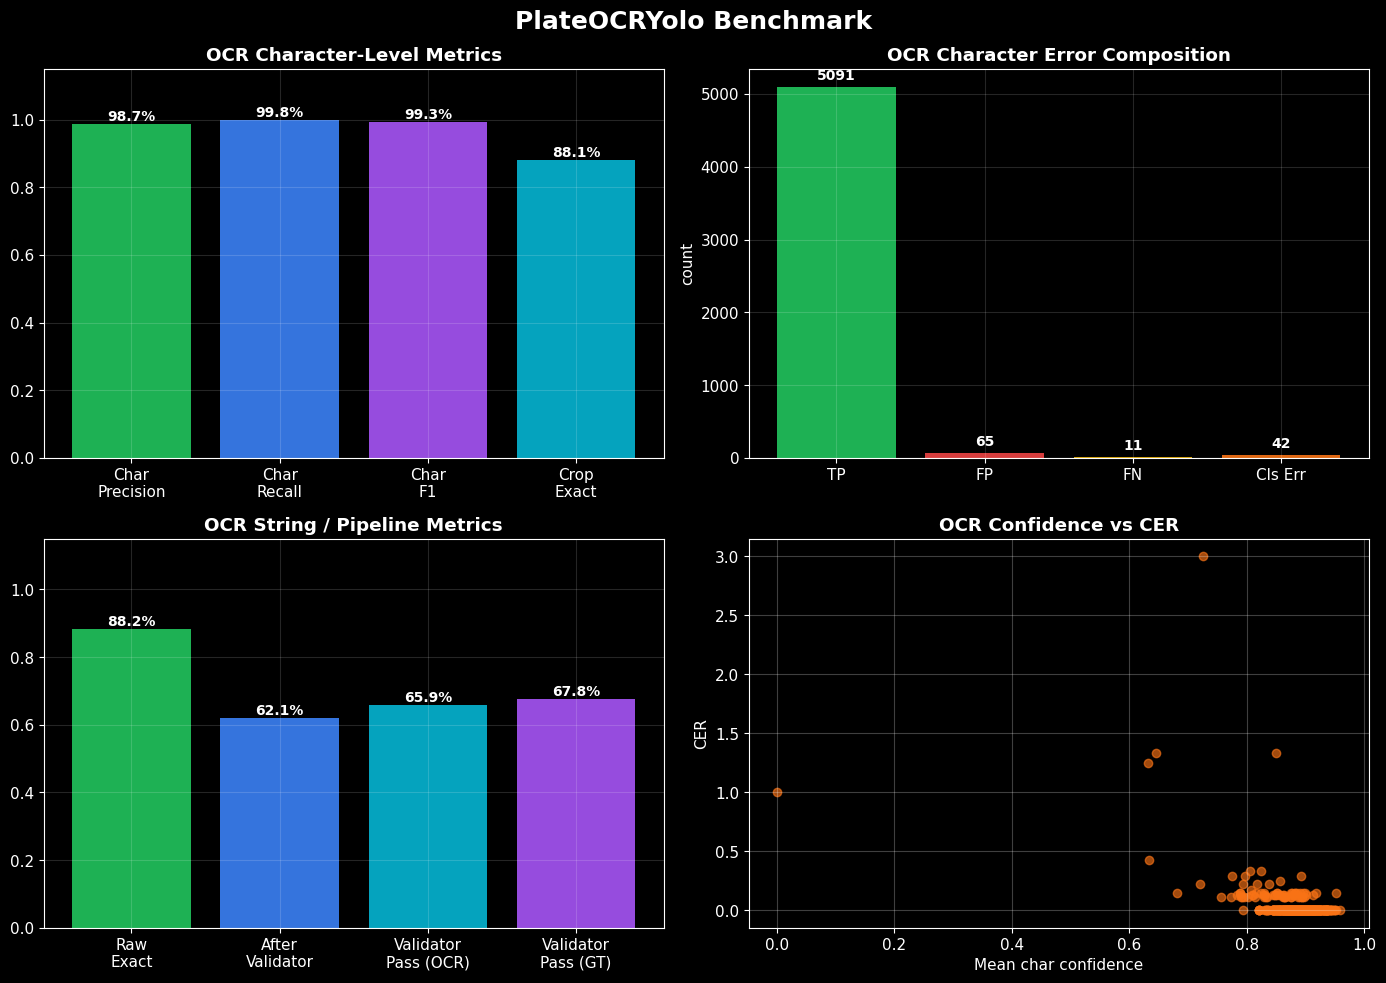

In [8]:
if ocr_bench and ocr_bench['char']['n_samples']:
    c = ocr_bench['char']
    tp, fp, fn = c['tp'], c['fp'], c['fn']
    prec = tp / max(tp + fp, 1)
    rec = tp / max(tp + fn, 1)
    f1 = 2 * prec * rec / max(prec + rec, 1e-6)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    char_metrics = ['Char\nPrecision', 'Char\nRecall', 'Char\nF1', 'Crop\nExact']
    char_vals = [prec, rec, f1, c['plate_exact'] / max(c['n_samples'], 1)]
    bars = axes[0,0].bar(char_metrics, char_vals,
                         color=[C['green'], C['blue'], C['purple'], C['cyan']], alpha=0.9)
    for b, v in zip(bars, char_vals):
        axes[0,0].text(b.get_x()+b.get_width()/2, v+0.01, f'{v*100:.1f}%',
                       ha='center', fontsize=10, fontweight='bold')
    axes[0,0].set_ylim(0,1.15)
    axes[0,0].set_title('OCR Character-Level Metrics', fontweight='bold')

    err_labels = ['TP', 'FP', 'FN', 'Cls Err']
    err_vals = [c['tp'], c['fp'], c['fn'], c['cls_err']]
    bars = axes[0,1].bar(err_labels, err_vals,
                         color=[C['green'], C['red'], C['yellow'], C['orange']], alpha=0.9)
    for b, v in zip(bars, err_vals):
        axes[0,1].text(b.get_x() + b.get_width() / 2, v + max(max(err_vals) * 0.02, 1), f'{v}',
                       ha='center', fontsize=10, fontweight='bold')
    axes[0,1].set_title('OCR Character Error Composition', fontweight='bold')
    axes[0,1].set_ylabel('count')

    s = ocr_bench['string']
    string_metrics = ['Raw\nExact', 'After\nValidator', 'Validator\nPass (OCR)', 'Validator\nPass (GT)']
    string_vals = [
        s['exact_raw'] / max(s['n'], 1),
        s['exact_valid'] / max(s['n'], 1),
        s['validator_pass_pred'] / max(s['n'], 1),
        s['validator_pass_gt'] / max(s['n'], 1),
    ]
    bars = axes[1,0].bar(string_metrics, string_vals,
                         color=[C['green'], C['blue'], C['cyan'], C['purple']], alpha=0.9)
    for b, v in zip(bars, string_vals):
        axes[1,0].text(b.get_x() + b.get_width() / 2, v + 0.01, f'{v*100:.1f}%',
                       ha='center', fontsize=10, fontweight='bold')
    axes[1,0].set_ylim(0, 1.15)
    axes[1,0].set_title('OCR String / Pipeline Metrics', fontweight='bold')

    cer_vals = s['cers'] if s['cers'] else [0.0]
    conf_vals = s['confs'] if s['confs'] else [0.0]
    axes[1,1].scatter(conf_vals, cer_vals, alpha=0.65, color=C['orange'])
    axes[1,1].set_xlabel('Mean char confidence')
    axes[1,1].set_ylabel('CER')
    axes[1,1].set_title('OCR Confidence vs CER', fontweight='bold')
    axes[1,1].grid(alpha=0.25)

    plt.suptitle('PlateOCRYolo Benchmark', fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()


---
## 3. FaceEngine — LFW Dataset
**Data**: LFW (Labeled Faces in the Wild) — ~13,000 ảnh mặt  
**Đo**: detection rate, same/diff person similarity, optimal threshold, latency

In [9]:
import os, glob, tarfile, urllib.request
from pathlib import Path
from collections import defaultdict

# ===== Paths =====
LFW_TGZ = str(PROJECT_DIR / 'benchmark_data' / 'lfw-funneled.tgz')
LFW_EXTRACT = str(PROJECT_DIR / 'benchmark_data')
LFW_ROOT = os.path.join(LFW_EXTRACT, 'lfw_funneled')

os.makedirs(LFW_EXTRACT, exist_ok=True)

# ===== Download URLs =====
LFW_URLS = [
    'https://ndownloader.figshare.com/files/5976015',   # mirror used by scikit-learn
    'http://vis-www.cs.umass.edu/lfw/lfw-funneled.tgz', # original source
]

def download_with_fallback(urls, dst):
    last_err = None
    for url in urls:
        try:
            print(f'Trying: {url}')
            urllib.request.urlretrieve(url, dst)
            print('Download OK')
            return url
        except Exception as e:
            print(f'Failed: {e}')
            last_err = e
            # xóa file lỗi / tải dở
            if os.path.exists(dst):
                try:
                    os.remove(dst)
                except:
                    pass
    raise RuntimeError(f'Cannot download LFW from any source. Last error: {last_err}')

# ===== Main =====
if os.path.isdir(LFW_ROOT) and len(os.listdir(LFW_ROOT)) > 100:
    print(f'✅ LFW exists: {LFW_ROOT}')
else:
    print('Downloading LFW...')
    if not os.path.exists(LFW_TGZ):
        used_url = download_with_fallback(LFW_URLS, LFW_TGZ)
        print(f'Used URL: {used_url}')
    else:
        print(f'Found existing archive: {LFW_TGZ}')

    print('Extracting...')
    with tarfile.open(LFW_TGZ, 'r:gz') as tar:
        tar.extractall(LFW_EXTRACT)
    print('Done.')

lfw_images = sorted(glob.glob(os.path.join(LFW_ROOT, '*', '*.jpg')))
print(f'LFW images: {len(lfw_images)}')

# Người có >= 2 ảnh
person_imgs = defaultdict(list)
for p in lfw_images:
    person_imgs[Path(p).parent.name].append(p)

multi = {k: v for k, v in person_imgs.items() if len(v) >= 2}
print(f'Persons with >= 2 images: {len(multi)}')

✅ LFW exists: /home/somethink/parking_system/benchmark_data/lfw_funneled
LFW images: 13233
Persons with >= 2 images: 1680


In [11]:
from engine import FaceEngine

print('Loading FaceEngine...')
face_eng = FaceEngine(model_pack='buffalo_sc', det_size=(640, 640))
print('Done.\n')

face_latency = []
print('=== FaceEngine Latency ===')
for name, (w,h) in [('640x480',(640,480)), ('1280x720',(1280,720))]:
    img = np.random.randint(0,255,(h,w,3), dtype=np.uint8)
    s = bench(lambda img=img: face_eng(img), n=N_BENCH, label=f'Face {name}')
    face_latency.append(s)

Loading FaceEngine...
Applied providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}, 'TensorrtExecutionProvider': {'trt_load_user_initializer': '0', 'trt_op_types_to_exclude': '', 'trt_external_data_bytestream': '0'

NvMapMemAllocInternalTagged: 1075072515 error 12
NvMapMemHandleAlloc: error 0


Applied providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}, 'TensorrtExecutionProvider': {'trt_load_user_initializer': '0', 'trt_op_types_to_exclude': '', 'trt_external_data_bytestream': '0', 'trt_preview_feature

In [12]:
# ── Detection rate trên LFW ──
N_SAMPLE = 200
sample = random.sample(lfw_images, min(N_SAMPLE, len(lfw_images)))

face_acc = {'detected':0, 'no_face':0, 'multi':0, 'confs':[], 'times_ms':[]}

for p in sample:
    img = cv2.imread(p)
    if img is None: continue
    t0 = time.perf_counter()
    faces = face_eng(img)
    face_acc['times_ms'].append((time.perf_counter()-t0)*1000)
    if len(faces)==0: face_acc['no_face']+=1
    elif len(faces)==1:
        face_acc['detected']+=1; face_acc['confs'].append(faces[0]['conf'])
    else:
        face_acc['multi']+=1; face_acc['confs'].append(max(f['conf'] for f in faces))

tot = face_acc['detected']+face_acc['no_face']+face_acc['multi']
print(f'=== Face Detection ({tot} images) ===')
print(f'  Detected: {face_acc["detected"]} ({100*face_acc["detected"]/max(tot,1):.1f}%)')
print(f'  No face:  {face_acc["no_face"]} ({100*face_acc["no_face"]/max(tot,1):.1f}%)')
print(f'  Multi:    {face_acc["multi"]}')

=== Face Detection (200 images) ===
  Detected: 174 (87.0%)
  No face:  1 (0.5%)
  Multi:    25


In [13]:
# ── Same vs Different person similarity ──
N_PAIRS = 100

def get_emb(path):
    img = cv2.imread(path)
    if img is None: return None
    faces = face_eng(img)
    return max(faces, key=lambda f: f['conf'])['embedding'] if faces else None

# Same person
same_sims = []
for name, imgs in list(multi.items()):
    if len(same_sims) >= N_PAIRS: break
    e1, e2 = get_emb(imgs[0]), get_emb(imgs[1])
    if e1 is not None and e2 is not None:
        same_sims.append(float(np.dot(e1, e2)))

# Different person
diff_sims = []
all_p = list(person_imgs.keys())
for _ in range(N_PAIRS * 5):
    if len(diff_sims) >= N_PAIRS: break
    p1, p2 = random.sample(all_p, 2)
    e1, e2 = get_emb(person_imgs[p1][0]), get_emb(person_imgs[p2][0])
    if e1 is not None and e2 is not None:
        diff_sims.append(float(np.dot(e1, e2)))

print(f'Same person  (n={len(same_sims)}):  mean={np.mean(same_sims):.3f}')
print(f'Diff person  (n={len(diff_sims)}):  mean={np.mean(diff_sims):.3f}')

# Best threshold
best_thr, best_acc = 0, 0
for thr in np.arange(0.0, 1.0, 0.01):
    tp = sum(1 for s in same_sims if s >= thr)
    tn = sum(1 for s in diff_sims if s < thr)
    acc = (tp+tn)/(len(same_sims)+len(diff_sims))
    if acc > best_acc: best_acc, best_thr = acc, thr

print(f'\nBest threshold: {best_thr:.2f} (acc={best_acc:.3f})')
print(f'Config threshold: 0.45  ({"OK ✅" if abs(best_thr-0.45)<0.15 else "KHÁC ⚠️"})')

Same person  (n=100):  mean=0.618
Diff person  (n=100):  mean=0.005

Best threshold: 0.21 (acc=0.995)
Config threshold: 0.45  (KHÁC ⚠️)


### Face Identity Accuracy (Top-1)
Đánh giá nhận diện danh tính trên tập người có **>=2 ảnh** (gallery/probe).


In [14]:
import csv
import os
from pathlib import Path

# ── Identity accuracy (Top-1) trên nhóm người có >=2 ảnh ──
rng = random.Random(42)
FACE_ID_ERROR_CSV = Path('/tmp/bench_face_id_errors.csv')
FACE_ID_SHOW_TOPK = 15

def get_single_face_emb(path):
    img = cv2.imread(path)
    if img is None:
        return None, 'no_face'
    faces = face_eng(img)
    if len(faces) == 0:
        return None, 'no_face'
    if len(faces) != 1:
        return None, 'multi_face'
    return faces[0]['embedding'], 'ok'

gallery_labels, gallery_embs, gallery_paths = [], [], []
probe_labels, probe_embs, probe_paths = [], [], []
id_stats = {
    'skip_gallery_no_face': 0,
    'skip_gallery_multi': 0,
    'skip_probe_no_face': 0,
    'skip_probe_multi': 0,
}

for name, imgs in multi.items():
    if len(imgs) < 2:
        continue
    # Mỗi identity: 1 ảnh gallery + 1 ảnh probe (random nhưng cố định seed)
    g_path, p_path = rng.sample(imgs, 2)

    g_emb, g_status = get_single_face_emb(g_path)
    if g_status != 'ok':
        if g_status == 'multi_face':
            id_stats['skip_gallery_multi'] += 1
        else:
            id_stats['skip_gallery_no_face'] += 1
        continue

    p_emb, p_status = get_single_face_emb(p_path)
    if p_status != 'ok':
        if p_status == 'multi_face':
            id_stats['skip_probe_multi'] += 1
        else:
            id_stats['skip_probe_no_face'] += 1
        continue

    gallery_labels.append(name)
    gallery_embs.append(g_emb)
    gallery_paths.append(g_path)
    probe_labels.append(name)
    probe_embs.append(p_emb)
    probe_paths.append(p_path)

if not probe_embs:
    print('Không đủ embedding hợp lệ để đánh giá Top-1 identity.')
else:
    G = np.vstack(gallery_embs).astype(np.float32)
    P = np.vstack(probe_embs).astype(np.float32)

    # embedding đã normalize => dot product = cosine similarity
    sim = P @ G.T
    pred_idx = np.argmax(sim, axis=1)
    pred_labels = [gallery_labels[i] for i in pred_idx]

    correct = sum(1 for p2, t in zip(pred_labels, probe_labels) if p2 == t)
    acc = correct / len(probe_labels)

    # Thống kê thêm: genuine vs best-imposter similarity
    label_to_idx = {lbl: i for i, lbl in enumerate(gallery_labels)}
    rows = np.arange(len(probe_labels))
    true_idx = np.array([label_to_idx[lbl] for lbl in probe_labels])
    genuine = sim[rows, true_idx]
    pred_sim = sim[rows, pred_idx]
    sim_masked = sim.copy()
    sim_masked[rows, true_idx] = -1e9
    best_imposter = sim_masked.max(axis=1)

    errors = []
    for i, (pred_lbl, true_lbl) in enumerate(zip(pred_labels, probe_labels)):
        if pred_lbl == true_lbl:
            continue
        true_gallery_idx = int(true_idx[i])
        pred_gallery_idx = int(pred_idx[i])
        errors.append({
            'true_label': true_lbl,
            'pred_label': pred_lbl,
            'probe_path': os.path.relpath(probe_paths[i], PROJECT_DIR),
            'true_gallery_path': os.path.relpath(gallery_paths[true_gallery_idx], PROJECT_DIR),
            'pred_gallery_path': os.path.relpath(gallery_paths[pred_gallery_idx], PROJECT_DIR),
            'true_sim': float(genuine[i]),
            'pred_sim': float(pred_sim[i]),
            'margin_pred_minus_true': float(pred_sim[i] - genuine[i]),
        })

    errors.sort(key=lambda x: x['margin_pred_minus_true'], reverse=True)
    fieldnames = [
        'true_label', 'pred_label', 'probe_path',
        'true_gallery_path', 'pred_gallery_path',
        'true_sim', 'pred_sim', 'margin_pred_minus_true'
    ]
    with FACE_ID_ERROR_CSV.open('w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(errors)

    print('=== Face Identity (Top-1, gallery/probe, single-face only) ===')
    print('  Identities evaluated: {}'.format(len(probe_labels)))
    print('  Correct: {}'.format(correct))
    print('  Top-1 accuracy: {:.4f} ({:.2f}%)'.format(acc, acc * 100))
    print('  Mean genuine sim: {:.4f}'.format(genuine.mean()))
    print('  Mean best-imposter sim: {:.4f}'.format(best_imposter.mean()))
    print('  Errors: {}'.format(len(errors)))
    print('  Error CSV: {}'.format(FACE_ID_ERROR_CSV))
    print('  Skipped gallery(no face): {}'.format(id_stats['skip_gallery_no_face']))
    print('  Skipped gallery(multi face): {}'.format(id_stats['skip_gallery_multi']))
    print('  Skipped probe(no face):   {}'.format(id_stats['skip_probe_no_face']))
    print('  Skipped probe(multi face): {}'.format(id_stats['skip_probe_multi']))

    if errors:
        print('')
        print('Top mismatches:')
        for rank, err in enumerate(errors[:FACE_ID_SHOW_TOPK], start=1):
            print(
                '  [{:02d}] true={} pred={} pred_sim={:.4f} true_sim={:.4f} margin={:.4f}'.format(
                    rank,
                    err['true_label'],
                    err['pred_label'],
                    err['pred_sim'],
                    err['true_sim'],
                    err['margin_pred_minus_true'],
                )
            )
            print('       probe: {}'.format(err['probe_path']))
            print('       true_gallery: {}'.format(err['true_gallery_path']))
            print('       pred_gallery: {}'.format(err['pred_gallery_path']))


=== Face Identity (Top-1, gallery/probe, single-face only) ===
  Identities evaluated: 1189
  Correct: 1178
  Top-1 accuracy: 0.9907 (99.07%)
  Mean genuine sim: 0.6170
  Mean best-imposter sim: 0.2455
  Errors: 11
  Error CSV: /tmp/bench_face_id_errors.csv
  Skipped gallery(no face): 5
  Skipped gallery(multi face): 273
  Skipped probe(no face):   5
  Skipped probe(multi face): 208

Top mismatches:
  [01] true=Michael_Schumacher pred=Rob_Marshall pred_sim=0.2071 true_sim=-0.0957 margin=0.3028
       probe: benchmark_data/lfw_funneled/Michael_Schumacher/Michael_Schumacher_0008.jpg
       true_gallery: benchmark_data/lfw_funneled/Michael_Schumacher/Michael_Schumacher_0011.jpg
       pred_gallery: benchmark_data/lfw_funneled/Rob_Marshall/Rob_Marshall_0005.jpg
  [02] true=Elisabeth_Schumacher pred=Carly_Fiorina pred_sim=0.2868 true_sim=0.0105 margin=0.2763
       probe: benchmark_data/lfw_funneled/Elisabeth_Schumacher/Elisabeth_Schumacher_0002.jpg
       true_gallery: benchmark_data/lfw_f

In [1]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Detection pie
axes[0,0].pie([face_acc['detected'],face_acc['no_face'],face_acc['multi']],
              labels=['Detected','No face','Multi'], colors=[C['green'],C['red'],C['yellow']],
              autopct='%1.1f%%', startangle=90, textprops={'fontsize':10})
axes[0,0].set_title(f'Detection Rate (n={tot})', fontweight='bold')

# 2) Same vs Diff similarity
axes[0,1].hist(same_sims, bins=25, color=C['green'], alpha=0.7,
               label=f'Same (n={len(same_sims)})', edgecolor='white', linewidth=0.3)
axes[0,1].hist(diff_sims, bins=25, color=C['red'], alpha=0.5,
               label=f'Diff (n={len(diff_sims)})', edgecolor='white', linewidth=0.3)
axes[0,1].axvline(best_thr, color='white', linestyle='--', label=f'best={best_thr:.2f}')
axes[0,1].axvline(0.45, color=C['yellow'], linestyle=':', label='config=0.45')
axes[0,1].set_title('Same vs Diff Person Similarity', fontweight='bold')
axes[0,1].set_xlabel('Cosine Similarity'); axes[0,1].legend(fontsize=8)

# 3) Confidence
if face_acc['confs']:
    axes[1,0].hist(face_acc['confs'], bins=25, color=C['blue'], alpha=0.85, edgecolor='white', linewidth=0.3)
    axes[1,0].set_title('Detection Confidence', fontweight='bold')

# 4) Latency
if face_acc['times_ms']:
    t_arr = np.array(face_acc['times_ms'])
    axes[1,1].hist(t_arr, bins=30, color=C['purple'], alpha=0.85, edgecolor='white', linewidth=0.3)
    axes[1,1].axvline(t_arr.mean(), color='white', linestyle='--', label=f'mean={t_arr.mean():.1f}ms')
    axes[1,1].set_title('Latency (LFW)', fontweight='bold'); axes[1,1].legend(fontsize=8)

plt.suptitle('FaceEngine — LFW Benchmark', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/bench_face.png', dpi=120, bbox_inches='tight')
plt.show()

NameError: name 'plt' is not defined

---
## 4. ParkingDB — pgvector (Real Embeddings from LFW)

In [12]:
from database import ParkingDB, DIM
import yaml

with open(str(PROJECT_DIR / 'config.yaml'), 'r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)
dcfg = cfg['database']
db = ParkingDB(host=dcfg['host'], port=dcfg['port'], dbname=dcfg['dbname'],
               user=dcfg['user'], password=dcfg['password'], max_cap=dcfg['max_capacity'])
print(f'DB stats: {db.stats()}')

# Collect real embeddings
print('Collecting LFW embeddings...')
real_embs = []
for p in random.sample(lfw_images, min(600, len(lfw_images))):
    img = cv2.imread(p)
    if img is None: continue
    faces = face_eng(img)
    if faces:
        real_embs.append(max(faces, key=lambda f:f['conf'])['embedding'])
    if len(real_embs) >= 500: break
print(f'Got {len(real_embs)} embeddings')

DB stats: {'current': 2, 'capacity': 500, 'pct': 0.4}
Got 500 embeddings


In [13]:
DB_SIZES = [10, 50, 100, 200, 500]
db_search_stats, db_insert_stats = [], []

for n in DB_SIZES:
    if n > len(real_embs):
        print(f'  Skip n={n}'); continue
    
    with db._conn() as conn:
        conn.cursor().execute("DELETE FROM active WHERE plate LIKE 'BM_%'")
    
    ids = []
    t0 = time.perf_counter()
    for i in range(n):
        r = db.entry(f'BM_{i:04d}', real_embs[i], 0.9, 0.8)
        if r > 0: ids.append(r)
    t_ins = (time.perf_counter()-t0)*1000
    db_insert_stats.append({'n':n, 'total_ms':t_ins, 'per_ms':t_ins/max(len(ids),1)})
    
    q = real_embs[min(n, len(real_embs)-1)]
    s = bench(lambda: db.match_exit(q, 0.3), n=min(N_BENCH,200), warmup=3, label=f'Search n={len(ids)}')
    db_search_stats.append(s)
    
    for rid in ids: db.exit(rid, 0.5)

print('\n=== Insert ===')
for s in db_insert_stats:
    print(f'  n={s["n"]:4d}  per_record={s["per_ms"]:.2f}ms')

  Search n=10                     avg=   8.43ms  p95=   9.59ms  fps= 118.6
  Search n=50                     avg=   9.10ms  p95=   9.73ms  fps= 109.9
  Search n=100                    avg=   9.15ms  p95=   9.31ms  fps= 109.3
  Search n=200                    avg=   9.18ms  p95=   9.35ms  fps= 108.9
  Search n=498                    avg=   9.38ms  p95=  13.06ms  fps= 106.6

=== Insert ===
  n=  10  per_record=11.87ms
  n=  50  per_record=7.57ms
  n= 100  per_record=7.23ms
  n= 200  per_record=7.18ms
  n= 500  per_record=7.18ms


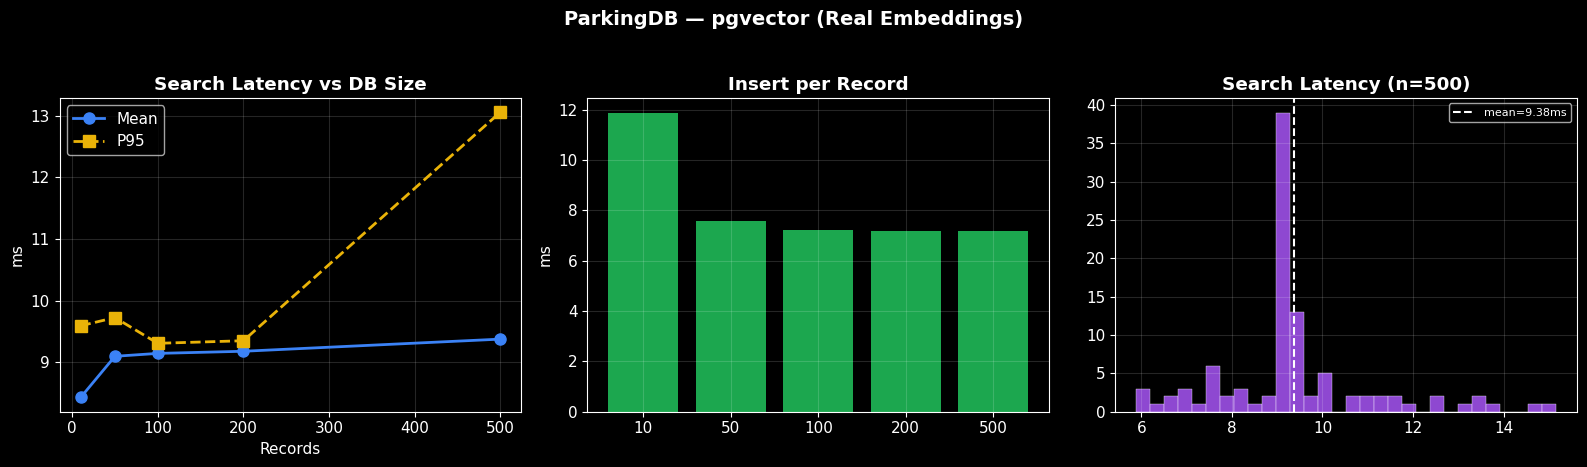

In [14]:
if db_search_stats:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    ns = [s['n'] for s in db_insert_stats]

    axes[0].plot(ns[:len(db_search_stats)], [s['mean'] for s in db_search_stats], 'o-',
                 color=C['blue'], label='Mean', linewidth=2, markersize=8)
    axes[0].plot(ns[:len(db_search_stats)], [s['p95'] for s in db_search_stats], 's--',
                 color=C['yellow'], label='P95', linewidth=2, markersize=8)
    axes[0].set_xlabel('Records'); axes[0].set_ylabel('ms')
    axes[0].set_title('Search Latency vs DB Size', fontweight='bold'); axes[0].legend()

    axes[1].bar(range(len(ns)), [s['per_ms'] for s in db_insert_stats],
                tick_label=[str(n) for n in ns], color=C['green'], alpha=0.85)
    axes[1].set_title('Insert per Record', fontweight='bold'); axes[1].set_ylabel('ms')

    last = db_search_stats[-1]
    axes[2].hist(last['raw'], bins=30, color=C['purple'], alpha=0.85, edgecolor='white', linewidth=0.3)
    axes[2].axvline(last['mean'], color='white', linestyle='--', label=f'mean={last["mean"]:.2f}ms')
    axes[2].set_title(f'Search Latency (n={ns[-1]})', fontweight='bold'); axes[2].legend(fontsize=8)

    plt.suptitle('ParkingDB — pgvector (Real Embeddings)', fontsize=14, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.savefig('/tmp/bench_db.png', dpi=120, bbox_inches='tight')
    plt.show()

---
## 5. End-to-End + Summary

In [ ]:
# ── E2E: Det → OCR → Validate → Face → DB ──

if HAS_DET:
    e2e_plates = sorted(glob.glob(os.path.join(DET_IMAGES_DIR,'*.jpg'))+
                        glob.glob(os.path.join(DET_IMAGES_DIR,'*.png')))[:100]
else:
    e2e_plates = None

e2e_faces = random.sample(lfw_images, min(100, len(lfw_images)))

# Seed DB
with db._conn() as conn:
    conn.cursor().execute("DELETE FROM active WHERE plate LIKE 'E2E_%'")
for i in range(min(50, len(real_embs))):
    db.entry(f'E2E_{i:03d}', real_embs[i], 0.9, 0.8)

e2e = {'plate_det':[], 'ocr':[], 'validate':[], 'face_det':[], 'quality':[], 'db_search':[], 'total':[]}
N_E2E = min(100, len(e2e_faces))

print(f'Running {N_E2E} E2E iterations...')
for i in range(N_E2E):
    tt = time.perf_counter()

    if e2e_plates:
        pimg = cv2.imread(e2e_plates[i % len(e2e_plates)])
    else:
        pimg = np.random.randint(0,255,(1280,1280,3), dtype=np.uint8)  # square cho TRT

    t0=time.perf_counter(); dets=plate_det(pad_to_square(pimg)); e2e['plate_det'].append((time.perf_counter()-t0)*1000)

    if dets:
        best=max(dets,key=lambda d:d['conf'])
        x1,y1,x2,y2=best['bbox']; h,w=pimg.shape[:2]
        bw,bh=x2-x1,y2-y1; mx,my=max(10,int(bw*0.08)),max(8,int(bh*0.12))
        crop=pimg[max(0,y1-my):min(h,y2+my),max(0,x1-mx):min(w,x2+mx)]
        t0=time.perf_counter(); raw,_=plate_ocr(crop); e2e['ocr'].append((time.perf_counter()-t0)*1000)
        t0=time.perf_counter(); validator(raw); e2e['validate'].append((time.perf_counter()-t0)*1000)

    fimg = cv2.imread(e2e_faces[i % len(e2e_faces)])
    if fimg is not None:
        t0=time.perf_counter(); faces=face_eng(fimg); e2e['face_det'].append((time.perf_counter()-t0)*1000)
        if faces:
            bf=max(faces,key=lambda f:f['conf'])
            t0=time.perf_counter(); FaceEngine.quality_score(fimg,bf['bbox']); e2e['quality'].append((time.perf_counter()-t0)*1000)
            t0=time.perf_counter(); db.match_exit(bf['embedding'],0.45); e2e['db_search'].append((time.perf_counter()-t0)*1000)

    e2e['total'].append((time.perf_counter()-tt)*1000)

with db._conn() as conn:
    conn.cursor().execute("DELETE FROM active WHERE plate LIKE 'E2E_%'")

total_avg = np.mean(e2e['total'])
print(f'\n{"Step":15s} {"Avg":>8s} {"P95":>8s} {"% total":>8s}')
print('-'*42)
for step in ['plate_det','ocr','validate','face_det','quality','db_search','total']:
    if not e2e[step]: continue
    a=np.array(e2e[step])
    pct = 100*a.mean()/total_avg if step!='total' else 100
    print(f'{step:15s} {a.mean():7.1f}ms {np.percentile(a,95):7.1f}ms {pct:7.1f}%')
print(f'\n→ E2E FPS: {1000/total_avg:.1f}')

Running 100 E2E iterations...


NameError: name 'plate_det' is not defined

: 

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

steps = ['plate_det','ocr','validate','face_det','quality','db_search']
snames = ['Plate Det','OCR','Validate','Face Det','Quality','DB Search']
scols = [C['blue'],C['green'],C['cyan'],C['purple'],C['orange'],C['pink']]
avgs = [np.mean(e2e[s]) if e2e[s] else 0 for s in steps]

left=0
for a,nm,co in zip(avgs,snames,scols):
    axes[0].barh(0, a, left=left, height=0.4, color=co, label=f'{nm}: {a:.1f}ms', alpha=0.9)
    if a>2: axes[0].text(left+a/2, 0, f'{a:.1f}', ha='center', va='center', fontsize=9, fontweight='bold')
    left+=a
axes[0].set_yticks([]); axes[0].set_xlabel('ms')
axes[0].set_title(f'Breakdown (total: {sum(avgs):.1f}ms)', fontweight='bold')
axes[0].legend(loc='upper right', fontsize=7)

nz = [(n,a,c) for n,a,c in zip(snames,avgs,scols) if a>0]
if nz:
    pn,pa,pc = zip(*nz)
    axes[1].pie(pa, labels=pn, colors=pc, autopct='%1.1f%%', startangle=90, textprops={'fontsize':9})
    axes[1].set_title('Time Distribution', fontweight='bold')

ta = np.array(e2e['total'])
axes[2].plot(ta, color=C['blue'], alpha=0.5, linewidth=0.8)
w=min(10,len(ta))
if w>1:
    r=np.convolve(ta,np.ones(w)/w,mode='valid')
    axes[2].plot(range(w-1,len(ta)),r,color=C['green'],linewidth=2,label=f'Rolling({w})')
axes[2].axhline(ta.mean(),color='white',linestyle='--',alpha=0.5,label=f'Mean: {ta.mean():.1f}ms')
axes[2].set_xlabel('Frame'); axes[2].set_ylabel('ms')
axes[2].set_title('Per-Frame Latency', fontweight='bold'); axes[2].legend(fontsize=8)

plt.suptitle('End-to-End Pipeline', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('/tmp/bench_e2e.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── Overall Summary ──
# Ưu tiên real-image latency. Fallback synthetic nếu không có real data.
all_stats = []

# PlateDetector: det_latency[1] = real images (nếu có), [0] = synthetic
if len(det_latency) >= 2:
    all_stats.append(det_latency[1])   # real images
elif det_latency:
    all_stats.append(det_latency[0])   # synthetic fallback

# OCR: ocr_latency[-1] = real crops (nếu có, luôn append cuối), ngược lại lấy 160x48 synthetic
if ocr_latency:
    if 'real' in ocr_latency[-1]['label'].lower():
        all_stats.append(ocr_latency[-1])   # real crops
    elif len(ocr_latency) >= 2:
        all_stats.append(ocr_latency[1])    # 160x48 synthetic fallback
    else:
        all_stats.append(ocr_latency[0])

# Face: face_latency[0] = 640x480 synthetic (chưa có real trong face_latency)
if len(face_latency) >= 1:
    all_stats.append(face_latency[0])

# DB: last = largest DB size
if db_search_stats:
    all_stats.append(db_search_stats[-1])

print('='*65)
print('  SUMMARY')
print('='*65)
print(f'{"Component":30s} {"Mean":>8s} {"P95":>8s} {"FPS":>8s}')
print('-'*65)
for s in all_stats:
    print(f'{s["label"]:30s} {s["mean"]:7.2f}ms {s["p95"]:7.2f}ms {s["fps"]:7.1f}')
if e2e['total']:
    t=np.array(e2e['total'])
    print(f'{"End-to-End":30s} {t.mean():7.2f}ms {np.percentile(t,95):7.2f}ms {1000/t.mean():7.1f}')
print('='*65)


In [ ]:
if all_stats:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Bar comparison
    labels=[s['label'] for s in all_stats]; means=[s['mean'] for s in all_stats]; p95s=[s['p95'] for s in all_stats]
    x=np.arange(len(labels)); w=0.3
    axes[0].bar(x-w/2,means,w,label='Mean',color=C['blue'],alpha=0.9)
    axes[0].bar(x+w/2,p95s,w,label='P95',color=C['yellow'],alpha=0.9)
    for i,v in enumerate(means): axes[0].text(i-w/2,v+0.3,f'{v:.1f}',ha='center',fontsize=9)
    axes[0].set_xticks(x); axes[0].set_xticklabels(labels,rotation=15,ha='right',fontsize=9)
    axes[0].set_ylabel('ms'); axes[0].set_title('Latency Comparison', fontweight='bold'); axes[0].legend()

    # Bottleneck Pareto
    total=sum(means); pcts=[m/total*100 for m in means]
    idx=np.argsort(means)[::-1]
    sl=[labels[i] for i in idx]; sm=[means[i] for i in idx]; sp=[pcts[i] for i in idx]
    bc=[C['red'] if p>40 else C['yellow'] if p>20 else C['green'] for p in sp]
    bars=axes[1].barh(sl,sm,color=bc,alpha=0.85,height=0.5)
    cum=np.cumsum(sm); ax2=axes[1].twiny()
    ax2.plot(cum/total*100,range(len(sl)),'wo-',markersize=6,linewidth=2,alpha=0.8)
    ax2.set_xlim(0,105); ax2.set_xlabel('Cumulative %',color='white',alpha=0.6)
    for b,m,p in zip(bars,sm,sp):
        axes[1].text(b.get_width()+0.3,b.get_y()+b.get_height()/2,
                     f'{m:.1f}ms ({p:.0f}%)',va='center',fontsize=10,fontweight='bold')
    axes[1].set_xlabel('ms'); axes[1].set_title('Bottleneck (Pareto)', fontweight='bold')
    axes[1].legend(handles=[
        mpatches.Patch(color=C['red'],label='>40%'),
        mpatches.Patch(color=C['yellow'],label='>20%'),
        mpatches.Patch(color=C['green'],label='<20%'),
    ], loc='lower right', fontsize=8)

    plt.suptitle('Overall Performance', fontsize=14, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.savefig('/tmp/bench_summary.png', dpi=120, bbox_inches='tight')
    plt.show()

In [ ]:
db.close()
print('\n✅ Benchmark complete!')
for f in sorted(glob.glob('/tmp/bench_*.png')):
    print(f'  {f} ({os.path.getsize(f)/1024:.0f}KB)')